In [1]:
from pathlib import Path
import sys
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data_etna"

sys.path.append(str(SRC_DIR))

import cause_trigger
import parameter_extraction

importlib.reload(cause_trigger)
importlib.reload(parameter_extraction)

from cause_trigger import (
    CauseTriggerConfig,
    run_cause_trigger,
    find_increase_split,
    diagnostics_to_dataframe,
)

from parameter_extraction import find_parameters

In [2]:
etna_path = DATA_DIR / "FINAL_ME01_scaled.csv"

etna = pd.read_csv(etna_path, parse_dates=["time"])

print(etna.shape)
display(etna.head())
display(etna.isna().mean().sort_values())

(768, 10)


,time,station,S_log_scaled,T_log_scaled,Y_log_scaled,CO2_3_scaled,AirTemp_3_scaled,Patm_3_scaled,WindSpeed_scaled,CO2_SO2_scaled
0,2008-04-12 00:00:00+00:00,ME01,2.692603,25.664743,-1.299533,-1.455485,0.360327,-1.961611,-0.674491,1.215113
1,2008-04-12 01:00:00+00:00,ME01,-0.583228,16.141637,-0.865800,-1.834143,1.681098,-1.993539,-0.357083,1.215113
2,2008-04-12 02:00:00+00:00,ME01,-0.664601,18.177854,2.136266,-1.479116,0.718089,-2.081343,-0.674491,1.215113
3,2008-04-12 03:00:00+00:00,ME01,-0.761296,0.396437,-0.327978,-1.644814,0.811697,-2.137218,-0.674491,1.215113
4,2008-04-12 04:00:00+00:00,ME01,-0.782105,-0.210310,-0.297283,-1.668445,0.578318,-2.129236,-0.674491,1.215113


time                0.0
station             0.0
S_log_scaled        0.0
T_log_scaled        0.0
Y_log_scaled        0.0
CO2_3_scaled        0.0
AirTemp_3_scaled    0.0
Patm_3_scaled       0.0
WindSpeed_scaled    0.0
CO2_SO2_scaled      0.0
dtype: float64

In [3]:
X_all = (
    etna
    .drop(columns=["station"], errors="ignore")
    .set_index("time")
    .sort_index()
)

X_all = X_all.select_dtypes(include=[np.number])

print(X_all.shape)
display(X_all.head())
display(X_all.isna().sum())

(768, 8)


,S_log_scaled,T_log_scaled,Y_log_scaled,CO2_3_scaled,AirTemp_3_scaled,Patm_3_scaled,WindSpeed_scaled,CO2_SO2_scaled
time,,,,,,,,
2008-04-12 00:00:00+00:00,2.692603,25.664743,-1.299533,-1.455485,0.360327,-1.961611,-0.674491,1.215113
2008-04-12 01:00:00+00:00,-0.583228,16.141637,-0.865800,-1.834143,1.681098,-1.993539,-0.357083,1.215113
2008-04-12 02:00:00+00:00,-0.664601,18.177854,2.136266,-1.479116,0.718089,-2.081343,-0.674491,1.215113
2008-04-12 03:00:00+00:00,-0.761296,0.396437,-0.327978,-1.644814,0.811697,-2.137218,-0.674491,1.215113
2008-04-12 04:00:00+00:00,-0.782105,-0.210310,-0.297283,-1.668445,0.578318,-2.129236,-0.674491,1.215113


S_log_scaled        0
T_log_scaled        0
Y_log_scaled        0
CO2_3_scaled        0
AirTemp_3_scaled    0
Patm_3_scaled       0
WindSpeed_scaled    0
CO2_SO2_scaled      0
dtype: int64

In [4]:
EFFECT = "Y_log_scaled"

ETNA_EVENT_TIME = pd.Timestamp("2008-05-12 06:28:00", tz="UTC")

MIN_I1_LENGTH = 48
MIN_I2_LENGTH = 48
MAX_LAGS = 6
ALPHA = 0.05

# Use the full available timestamp range in the uploaded dataset.
X_FULL = X_all.copy()
df_model = X_FULL.copy()

print("Effect variable:", EFFECT)
print("Using full dataset time range")
print("Shape:", X_FULL.shape)
print("Start:", X_FULL.index.min())
print("End:", X_FULL.index.max())
print("Known event time:", ETNA_EVENT_TIME)

display(X_FULL.head())
display(X_FULL.tail())

Effect variable: Y_log_scaled
Using full dataset time range
Shape: (768, 8)
Start: 2008-04-12 00:00:00+00:00
End: 2008-05-13 23:00:00+00:00
Known event time: 2008-05-12 06:28:00+00:00


,S_log_scaled,T_log_scaled,Y_log_scaled,CO2_3_scaled,AirTemp_3_scaled,Patm_3_scaled,WindSpeed_scaled,CO2_SO2_scaled
time,,,,,,,,
2008-04-12 00:00:00+00:00,2.692603,25.664743,-1.299533,-1.455485,0.360327,-1.961611,-0.674491,1.215113
2008-04-12 01:00:00+00:00,-0.583228,16.141637,-0.865800,-1.834143,1.681098,-1.993539,-0.357083,1.215113
2008-04-12 02:00:00+00:00,-0.664601,18.177854,2.136266,-1.479116,0.718089,-2.081343,-0.674491,1.215113
2008-04-12 03:00:00+00:00,-0.761296,0.396437,-0.327978,-1.644814,0.811697,-2.137218,-0.674491,1.215113
2008-04-12 04:00:00+00:00,-0.782105,-0.210310,-0.297283,-1.668445,0.578318,-2.129236,-0.674491,1.215113


,S_log_scaled,T_log_scaled,Y_log_scaled,CO2_3_scaled,AirTemp_3_scaled,Patm_3_scaled,WindSpeed_scaled,CO2_SO2_scaled
time,,,,,,,,
2008-05-13 19:00:00+00:00,2.631722,0.718372,-0.143729,1.029518,-0.587294,-0.780254,1.785417,0.411903
2008-05-13 20:00:00+00:00,2.514733,-0.272517,1.640253,1.763157,-0.534720,-0.676486,0.714167,0.411903
2008-05-13 21:00:00+00:00,9.509822,3.119546,3.627575,1.621183,-0.564213,-0.664513,0.357083,0.411903
2008-05-13 22:00:00+00:00,1.830877,-0.290395,1.658494,1.976164,-0.565495,-0.736352,-0.674491,0.411903
2008-05-13 23:00:00+00:00,1.314704,-0.267208,1.009577,1.999842,-0.580883,-0.895995,-0.674491,0.411903


In [5]:
def split_diagnostics(
    X,
    effect,
    event_time=None,
    min_I1_length=48,
    min_I2_length=48,
):
    split_idx = find_increase_split(
        X[effect],
        min_I1_length=min_I1_length,
        min_I2_length=min_I2_length,
    )

    if split_idx is None:
        return {
            "effect": effect,
            "split_index": None,
            "split_time": None,
            "I1_length": None,
            "I2_length": None,
            "abs_mean_I1": None,
            "abs_mean_I2": None,
            "abs_mean_difference": None,
            "distance_to_event": None,
        }

    I1 = X.iloc[:split_idx]
    I2 = X.iloc[split_idx:]
    split_time = X.index[split_idx]

    out = {
        "effect": effect,
        "split_index": split_idx,
        "split_time": split_time,
        "I1_length": len(I1),
        "I2_length": len(I2),
        "abs_mean_I1": abs(I1[effect].mean()),
        "abs_mean_I2": abs(I2[effect].mean()),
        "abs_mean_difference": abs(I2[effect].mean()) - abs(I1[effect].mean()),
        "distance_to_event": None,
    }

    if event_time is not None:
        out["distance_to_event"] = split_time - event_time

    return out


split_table = pd.DataFrame([
    split_diagnostics(
        X_FULL,
        effect=EFFECT,
        event_time=ETNA_EVENT_TIME,
        min_I1_length=MIN_I1_LENGTH,
        min_I2_length=MIN_I2_LENGTH,
    )
])

display(split_table)

,effect,split_index,split_time,I1_length,I2_length,abs_mean_I1,abs_mean_I2,abs_mean_difference,distance_to_event
0,Y_log_scaled,76,2008-04-15 04:00:00+00:00,76,692,0.018071,2.605972,2.587901,-28 days +21:32:00


In [6]:
def summarize_result(result):
    print("Backend:", result.get("backend"))
    print("Configured lags:", result.get("configured_lags"))
    print("Configured distribution:", result.get("configured_distribution"))
    print("Parameter source:", result.get("parameter_source"))
    print("Split index:", result.get("split_index"))
    print("Split timestamp:", result.get("split_timestamp"))
    print("I1 length:", result.get("I1_length"))
    print("I2 length:", result.get("I2_length"))
    print("Effect abs mean difference:", result.get("target_abs_mean_difference"))
    print("B2:", result.get("B_2"))
    print("Autoregressive effect parent in B2:", result.get("autoregressive_parent_in_B2"))
    print("Trigger candidates:", result.get("T_candidates"))
    print("Accepted triggers:", result.get("T"))
    print("Causes:", result.get("C"))
    print("Cause-trigger pairs:", result.get("pairs"))

    scores = result.get("causal_scores", {})
    if "_hmml_metadata" in scores:
        print("HMML metadata:", scores["_hmml_metadata"])

    if result.get("selected_cause_shift_scores"):
        shift_scores = (
            pd.Series(result["selected_cause_shift_scores"])
            .sort_values(ascending=False)
            .to_frame("abs_mean_shift")
        )
        print("Cause-selection shift scores, excluding effect:")
        display(shift_scores)

    diag = diagnostics_to_dataframe(result)

    if len(diag) > 0:
        if "rss_reduction_ratio" in diag.columns:
            diag = diag.sort_values("rss_reduction_ratio", ascending=False)

        display(diag)

    return diag

In [7]:
config_pcmci_effect_manual = CauseTriggerConfig(
    y_t=EFFECT,
    lags=3,
    distribution="gaussian",
    causal_backend="pcmci",
    alpha=ALPHA,
    min_I1_length=MIN_I1_LENGTH,
    min_I2_length=MIN_I2_LENGTH,
    beta_is_ones=True,
    parameter_source="manual_lag3_gaussian_full_dataset",

    pcmci_pc_alpha=0.05,
    pcmci_alpha_level=0.05,
    pcmci_fdr_method="fdr_bh",
    pcmci_cond_ind_test="parcorr",
    pcmci_verbosity=0,
)

result_pcmci_effect_manual = run_cause_trigger(X_FULL, config_pcmci_effect_manual)
diag_pcmci_effect_manual = summarize_result(result_pcmci_effect_manual)

print("PCMCI causal lags:")
display(result_pcmci_effect_manual.get("causal_lags"))

print("PCMCI causal scores:")
display(result_pcmci_effect_manual.get("causal_scores"))

Backend: pcmci
Configured lags: 3
Configured distribution: gaussian
Parameter source: manual_lag3_gaussian_full_dataset
Split index: 76
Split timestamp: 2008-04-15 04:00:00+00:00
I1 length: 76
I2 length: 692
Effect abs mean difference: 2.587900721335371
B2: ['Y_log_scaled']
Autoregressive effect parent in B2: True
Trigger candidates: []
Accepted triggers: []
Causes: []
Cause-trigger pairs: []
Cause-selection shift scores, excluding effect:


,abs_mean_shift
CO2_3_scaled,1.418779
S_log_scaled,0.935347
CO2_SO2_scaled,0.897580
WindSpeed_scaled,0.493979
T_log_scaled,0.192356
Patm_3_scaled,0.085352
AirTemp_3_scaled,0.078757


PCMCI causal lags:


{'Y_log_scaled': [1, 2, 3]}

PCMCI causal scores:


{'Y_log_scaled': {'min_q': 1.4129845093584917e-29,
  'max_abs_val': 0.4235027078355769,
  'best_lag': 1}}

In [8]:
config_hmml_effect_manual = CauseTriggerConfig(
    y_t=EFFECT,
    lags=3,
    distribution="gaussian",
    causal_backend="hmml",
    alpha=ALPHA,
    min_I1_length=MIN_I1_LENGTH,
    min_I2_length=MIN_I2_LENGTH,
    beta_is_ones=True,
    parameter_source="manual_lag3_gaussian_full_dataset",
)

result_hmml_effect_manual = run_cause_trigger(X_FULL, config_hmml_effect_manual)
diag_hmml_effect_manual = summarize_result(result_hmml_effect_manual)

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom


Backend: hmml
Configured lags: 3
Configured distribution: gaussian
Parameter source: manual_lag3_gaussian_full_dataset
Split index: 76
Split timestamp: 2008-04-15 04:00:00+00:00
I1 length: 76
I2 length: 692
Effect abs mean difference: 2.587900721335371
B2: ['Y_log_scaled']
Autoregressive effect parent in B2: True
Trigger candidates: []
Accepted triggers: []
Causes: []
Cause-trigger pairs: []
HMML metadata: {'requested_distribution': 'gaussian', 'used_distribution': 'gaussian', 'used_fallback': False}
Cause-selection shift scores, excluding effect:


,abs_mean_shift
CO2_3_scaled,1.418779
S_log_scaled,0.935347
CO2_SO2_scaled,0.897580
WindSpeed_scaled,0.493979
T_log_scaled,0.192356
Patm_3_scaled,0.085352
AirTemp_3_scaled,0.078757


In [9]:
# Use VAR/AIC to select lag, but force Gaussian because variables are standardized
# and can contain negative values.
_, selected_lag = find_parameters(
    X=X_FULL,
    target_series=X_FULL[EFFECT],
    max_lags=MAX_LAGS,
    criterion="aic",
    fallback_lag=1,
    fallback_distribution="gaussian",
)

selected_distribution = "gaussian"

config_hmml_effect_auto = CauseTriggerConfig(
    y_t=EFFECT,
    lags=selected_lag,
    distribution=selected_distribution,
    causal_backend="hmml",
    alpha=ALPHA,
    min_I1_length=MIN_I1_LENGTH,
    min_I2_length=MIN_I2_LENGTH,
    beta_is_ones=True,
    parameter_source="VAR_AIC_lag_gaussian_scaled_full_dataset",
)

print("Effect:", EFFECT)
print("Selected lag:", selected_lag)
print("Forced distribution:", selected_distribution)

result_hmml_effect_auto = run_cause_trigger(X_FULL, config_hmml_effect_auto)
diag_hmml_effect_auto = summarize_result(result_hmml_effect_auto)

Effect: Y_log_scaled
Selected lag: 6
Forced distribution: gaussian


c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom


Backend: hmml
Configured lags: 6
Configured distribution: gaussian
Parameter source: VAR_AIC_lag_gaussian_scaled_full_dataset
Split index: 76
Split timestamp: 2008-04-15 04:00:00+00:00
I1 length: 76
I2 length: 692
Effect abs mean difference: 2.587900721335371
B2: ['Y_log_scaled']
Autoregressive effect parent in B2: True
Trigger candidates: []
Accepted triggers: []
Causes: []
Cause-trigger pairs: []
HMML metadata: {'requested_distribution': 'gaussian', 'used_distribution': 'gaussian', 'used_fallback': False}
Cause-selection shift scores, excluding effect:


,abs_mean_shift
CO2_3_scaled,1.418779
S_log_scaled,0.935347
CO2_SO2_scaled,0.897580
WindSpeed_scaled,0.493979
T_log_scaled,0.192356
Patm_3_scaled,0.085352
AirTemp_3_scaled,0.078757


In [10]:
def compact_result_row(name, effect, result):
    return {
        "run": name,
        "effect": effect,
        "backend": result.get("backend"),
        "parameter_source": result.get("parameter_source"),
        "configured_lags": result.get("configured_lags"),
        "configured_distribution": result.get("configured_distribution"),
        "split_index": result.get("split_index"),
        "split_timestamp": result.get("split_timestamp"),
        "I1_length": result.get("I1_length"),
        "I2_length": result.get("I2_length"),
        "B2": result.get("B_2"),
        "autoregressive_effect_parent_in_B2": result.get("autoregressive_parent_in_B2"),
        "trigger_candidates": result.get("T_candidates"),
        "accepted_triggers": result.get("T"),
        "causes": result.get("C"),
        "pairs": result.get("pairs"),
    }


comparison = pd.DataFrame([
    compact_result_row("pcmci_effect_manual", EFFECT, result_pcmci_effect_manual),
    compact_result_row("hmml_effect_manual", EFFECT, result_hmml_effect_manual),
    compact_result_row("hmml_effect_auto_lag", EFFECT, result_hmml_effect_auto),
])

display(comparison)

,run,effect,backend,parameter_source,configured_lags,configured_distribution,split_index,split_timestamp,I1_length,I2_length,B2,autoregressive_effect_parent_in_B2,trigger_candidates,accepted_triggers,causes,pairs
0,pcmci_effect_manual,Y_log_scaled,pcmci,manual_lag3_gaussian_full_dataset,3,gaussian,76,2008-04-15 04:00:00+00:00,76,692,[Y_log_scaled],True,[],[],[],[]
1,hmml_effect_manual,Y_log_scaled,hmml,manual_lag3_gaussian_full_dataset,3,gaussian,76,2008-04-15 04:00:00+00:00,76,692,[Y_log_scaled],True,[],[],[],[]
2,hmml_effect_auto_lag,Y_log_scaled,hmml,VAR_AIC_lag_gaussian_scaled_full_dataset,6,gaussian,76,2008-04-15 04:00:00+00:00,76,692,[Y_log_scaled],True,[],[],[],[]


In [11]:
def add_run_label(diag, run_name, effect, backend, parameter_source):
    if diag is None or len(diag) == 0:
        return pd.DataFrame()

    out = diag.copy()
    out["run"] = run_name
    out["effect"] = effect
    out["backend"] = backend
    out["parameter_source"] = parameter_source
    return out


all_diag = pd.concat(
    [
        add_run_label(
            diag_pcmci_effect_manual,
            "pcmci_effect_manual",
            EFFECT,
            "pcmci",
            "manual_lag3_gaussian_full_dataset",
        ),
        add_run_label(
            diag_hmml_effect_manual,
            "hmml_effect_manual",
            EFFECT,
            "hmml",
            "manual_lag3_gaussian_full_dataset",
        ),
        add_run_label(
            diag_hmml_effect_auto,
            "hmml_effect_auto_lag",
            EFFECT,
            "hmml",
            "VAR_AIC_lag_gaussian_scaled_full_dataset",
        ),
    ],
    ignore_index=True,
)

if len(all_diag) > 0:
    sort_columns = [c for c in ["accepted", "p_value", "rss_reduction_ratio"] if c in all_diag.columns]
    ascending = [False, True, False][:len(sort_columns)]

    display(
        all_diag.sort_values(
            sort_columns,
            ascending=ascending,
        )
    )
else:
    display(all_diag)

""


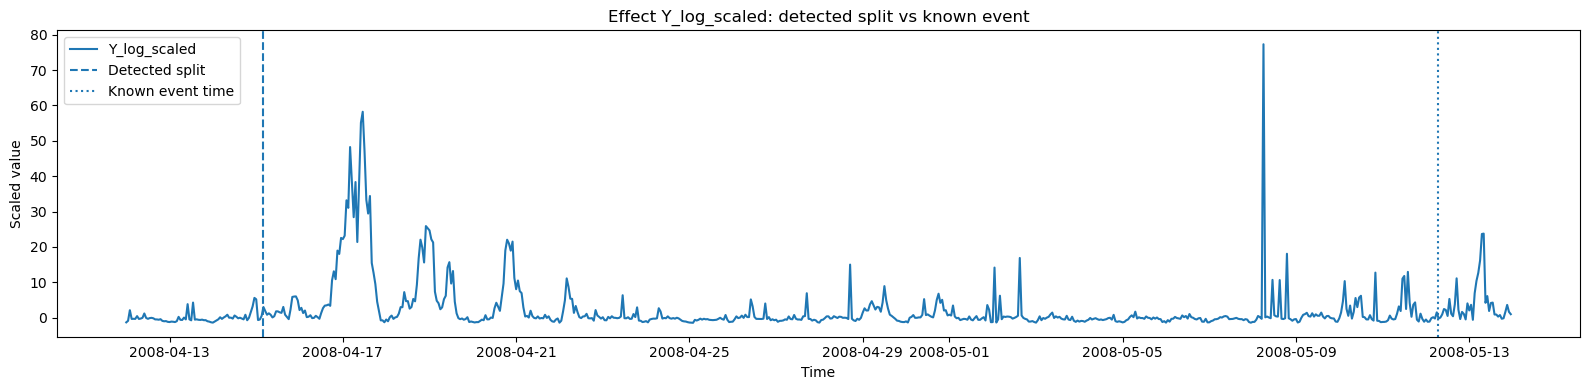

In [13]:
def plot_effect_with_split(df, effect, result, event_time=None):
    plt.figure(figsize=(16, 4))
    plt.plot(df.index, df[effect], label=effect)

    split_timestamp = result.get("split_timestamp")
    if split_timestamp is not None:
        plt.axvline(split_timestamp, linestyle="--", label="Detected split")

    if event_time is not None:
        event_time = pd.Timestamp(event_time)
        plt.axvline(event_time, linestyle=":", label="Known event time")

    plt.title(f"Effect {effect}: detected split vs known event")
    plt.xlabel("Time")
    plt.ylabel("Scaled value")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_effect_with_split(
    df=X_FULL,
    effect=EFFECT,
    result=result_hmml_effect_auto,
    event_time=ETNA_EVENT_TIME,
)

In [14]:
def print_split_event_distance(result, event_time):
    split_time = result.get("split_timestamp")

    if split_time is None:
        print("No valid split found.")
        return

    print("Detected split:", split_time)
    print("Known event time:", event_time)
    print("Distance split - event:", split_time - event_time)


print_split_event_distance(result_hmml_effect_auto, ETNA_EVENT_TIME)

Detected split: 2008-04-15 04:00:00+00:00
Known event time: 2008-05-12 06:28:00+00:00
Distance split - event: -28 days +21:32:00


In [15]:
def run_sensitivity_grid(
    df_model,
    effect,
    backends=("hmml", "pcmci"),
    lags=(1, 2, 3),
    distributions=("gaussian",),
    min_I1_length=48,
    min_I2_length=48,
):
    rows = []

    for backend in backends:
        for lag in lags:
            for distribution in distributions:
                config = CauseTriggerConfig(
                    y_t=effect,
                    lags=lag,
                    distribution=distribution,
                    causal_backend=backend,
                    alpha=ALPHA,
                    min_I1_length=min_I1_length,
                    min_I2_length=min_I2_length,
                    beta_is_ones=True,
                    parameter_source="sensitivity_grid",
                )

                try:
                    result = run_cause_trigger(df_model, config)
                    diagnostics = diagnostics_to_dataframe(result)

                    rows.append({
                        "effect": effect,
                        "backend": backend,
                        "lag": lag,
                        "distribution": distribution,
                        "split_timestamp": result.get("split_timestamp"),
                        "I1_length": result.get("I1_length"),
                        "I2_length": result.get("I2_length"),
                        "B_2": result.get("B_2"),
                        "autoregressive_effect_parent_in_B2": result.get("autoregressive_parent_in_B2"),
                        "trigger_candidates": result.get("T_candidates"),
                        "accepted_triggers": result.get("T"),
                        "causes": result.get("C"),
                        "pairs": result.get("pairs"),
                        "n_diagnostics": len(diagnostics),
                        "min_p_value": diagnostics["p_value"].min()
                            if "p_value" in diagnostics.columns and len(diagnostics) > 0
                            else None,
                        "max_rss_reduction_ratio": diagnostics["rss_reduction_ratio"].max()
                            if "rss_reduction_ratio" in diagnostics.columns and len(diagnostics) > 0
                            else None,
                    })

                except Exception as e:
                    rows.append({
                        "effect": effect,
                        "backend": backend,
                        "lag": lag,
                        "distribution": distribution,
                        "error": str(e),
                    })

    return pd.DataFrame(rows)


sensitivity_df = run_sensitivity_grid(
    df_model=X_FULL,
    effect=EFFECT,
    backends=("hmml", "pcmci"),
    lags=tuple(range(1, MAX_LAGS + 1)),
    distributions=("gaussian",),
    min_I1_length=MIN_I1_LENGTH,
    min_I2_length=MIN_I2_LENGTH,
)

display(sensitivity_df)

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) *

,effect,backend,lag,distribution,split_timestamp,I1_length,I2_length,B_2,autoregressive_effect_parent_in_B2,trigger_candidates,accepted_triggers,causes,pairs,n_diagnostics,min_p_value,max_rss_reduction_ratio
0,Y_log_scaled,hmml,1,gaussian,2008-04-15 04:00:00+00:00,76,692,"[Y_log_scaled, WindSpeed_scaled]",True,[WindSpeed_scaled],[],[],[],1,0.352831,0.001253
1,Y_log_scaled,hmml,2,gaussian,2008-04-15 04:00:00+00:00,76,692,[Y_log_scaled],True,[],[],[],[],0,NaN,NaN
2,Y_log_scaled,hmml,3,gaussian,2008-04-15 04:00:00+00:00,76,692,[Y_log_scaled],True,[],[],[],[],0,NaN,NaN
3,Y_log_scaled,hmml,4,gaussian,2008-04-15 04:00:00+00:00,76,692,[Y_log_scaled],True,[],[],[],[],0,NaN,NaN
4,Y_log_scaled,hmml,5,gaussian,2008-04-15 04:00:00+00:00,76,692,[Y_log_scaled],True,[],[],[],[],0,NaN,NaN
5,Y_log_scaled,hmml,6,gaussian,2008-04-15 04:00:00+00:00,76,692,[Y_log_scaled],True,[],[],[],[],0,NaN,NaN
6,Y_log_scaled,pcmci,1,gaussian,2008-04-15 04:00:00+00:00,76,692,[Y_log_scaled],True,[],[],[],[],0,NaN,NaN
7,Y_log_scaled,pcmci,2,gaussian,2008-04-15 04:00:00+00:00,76,692,[Y_log_scaled],True,[],[],[],[],0,NaN,NaN
8,Y_log_scaled,pcmci,3,gaussian,2008-04-15 04:00:00+00:00,76,692,[Y_log_scaled],True,[],[],[],[],0,NaN,NaN
9,Y_log_scaled,pcmci,4,gaussian,2008-04-15 04:00:00+00:00,76,692,[Y_log_scaled],True,[],[],[],[],0,NaN,NaN


In [16]:
accepted_sensitivity = sensitivity_df[
    sensitivity_df["accepted_triggers"].apply(lambda x: isinstance(x, list) and len(x) > 0)
].copy()

print("Sensitivity runs with accepted triggers:")
display(accepted_sensitivity)

if len(accepted_sensitivity) == 0:
    print("No accepted triggers for the effect under the tested full-dataset configurations.")
else:
    print("Accepted trigger configurations found. Check whether they are stable across lag/backend.")

Sensitivity runs with accepted triggers:


,effect,backend,lag,distribution,split_timestamp,I1_length,I2_length,B_2,autoregressive_effect_parent_in_B2,trigger_candidates,accepted_triggers,causes,pairs,n_diagnostics,min_p_value,max_rss_reduction_ratio


No accepted triggers for the effect under the tested full-dataset configurations.
